In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.pipeline import Pipeline

In [ ]:
df = pd.read_csv("/content/eda_modified_data.csv")

Removing the unwanted columns

In [ ]:
target_col = "PAM50Call_RNAseq"

remove_cols = [
    'PATIENT',
    'OS', 'OS.time',
    'DSS', 'DSS.time',
    'DFI', 'DFI.time',
    'PFI', 'PFI.time',
    'age_at_initial_pathologic_diagnosis',
    'gender',
    'ER_Status_nature2012',
    'PR_Status_nature2012',
    'HER2_Final_Status_nature2012',
    'final_stage'
]

# Remove unwanted columns
df = df.drop(columns=[col for col in remove_cols if col in df.columns])

# Remove missing target rows
df = df.dropna(subset=[target_col])

# Separate features and target
X = df.drop(columns=[target_col, 'sample_id']) # Added 'sample_id' to be dropped
y = df[target_col]

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(le.classes_)

['Basal' 'Her2' 'LumA' 'LumB' 'Normal']


In [ ]:
# Ensure all columns in X are numeric
for col in X.columns:
    # Attempt to convert to numeric, coercing errors to NaN
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Drop any columns that became entirely NaN (meaning they were entirely non-numeric)
X = X.dropna(axis=1, how='all')

print(f"X DataFrame shape after numeric conversion: {X.shape}")
print(f"Number of non-numeric columns remaining: {len(X.select_dtypes(include=['object', 'category']).columns)}")

X DataFrame shape after numeric conversion: (615, 20532)
Number of non-numeric columns remaining: 0


In [ ]:
selector = SelectKBest(score_func=f_classif, k=100)

X_selected = selector.fit_transform(X, y_encoded)

selected_features = X.columns[selector.get_support()]

print(selected_features)

Index(['THSD4', 'ART3', 'ABAT', 'SIDT1', 'GPR77', 'TTC8', 'TBC1D9', 'C4orf34',
       'FSIP1', 'B3GNT5', 'RABEP1', 'ZNF552', 'NAT1', 'INPP4B', 'TTLL4',
       'FLJ45983', 'CCNE1', 'MLPH', 'CHODL', 'FOXC1', 'CA12', 'AGR2', 'AGR3',
       'FAM47E', 'SFRS13B', 'MIA', 'AFF3', 'FAM171A1', 'SLC7A8', 'PRSS33',
       'PPP1R14C', 'SCUBE2', 'TTC36', 'HORMAD1', 'GFRA1', 'KCNJ11', 'AR',
       'CMBL', 'A2ML1', 'CCDC125', 'BCAS1', 'ESR1', 'MAPT', 'CT62', 'CACNA2D2',
       'GPR160', 'REEP6', 'XBP1', 'DNALI1', 'PRR15', 'IFRD1', 'ERBB4',
       'CLSTN2', 'NOSTRIN', 'ANXA9', 'C9orf170', 'ROPN1', 'MICALL1', 'C1orf64',
       'GDF5', 'SLC44A4', 'C6orf97', 'POU5F1', 'DEGS2', 'APBB2', 'GATA3',
       'FBP1', 'ACADSB', 'FOXA1', 'ROPN1B', 'LEMD1', 'CXXC5', 'KIAA1370',
       'KCNK15', 'KDM4B', 'RHOB', 'TFF3', 'SPDEF', 'FZD9', 'SERPINA11',
       'C5orf36', 'AMY1A', 'CXorf61', 'TFF1', 'ARSG', 'CENPN', 'CENPA',
       'CENPW', 'YBX1', 'GREB1', 'VGLL1', 'BCL11A', 'ANKRA2', 'PSAT1',
       'ZMYND10', 'OLAH', '

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [   43   146   216   285   286   299   323   367   567   734   821   825
   826   827   841  1079  1102  1190  1257  1258  1261  1340  1365  1366
  1369  1401  1427  1432  1463  1621  1657  1745  1767  1768  1893  1995
  1996  2005  2033  2034  2226  2227  2233  2238  2250  2254  2393  2478
  2693  2695  2700  2701  2735  2891  2905  3041  3050  3051  3078  3081
  3275  3286  3290  3427  3465  3538  3897  3996  4038  4052  4053  4054
  4137  4207  4480  4557  4807  4935  5011  5035  5132  5244  5301  5373
  5420  5441  5608  5609  5611  5617  5647  5650  5757  6032  6051  6053
  6120  6127  6149  6325  6326  6827  6854  6857  6858  7209  7220  7359
  7405  7422  7423  7442  7604  7652  7802  7859  7860  7915  8002  8027
  8109  8278  8567  9031  9140  9202  9307  9367  9487  9623  9627  9668
  9757 10264 10317 10460 10466 10504 10529 10530 10532 10587 10607 10610
 10670

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_selected)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [ ]:
X_train.shape

(492, 100)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "SVM": SVC(kernel='rbf'),

    "XGBoost": XGBClassifier(
        eval_metric='mlogloss',
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        random_state=42
    )
}

In [ ]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results[name] = acc

    print(f"\n{name}")
    print("Accuracy:", acc)

    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.8780487804878049
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        21
           1       0.88      0.70      0.78        10
           2       0.93      0.92      0.92        60
           3       0.76      0.90      0.83        29
           4       0.00      0.00      0.00         3

    accuracy                           0.88       123
   macro avg       0.70      0.69      0.70       123
weighted avg       0.87      0.88      0.87       123


Random Forest
Accuracy: 0.8780487804878049
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        21
           1       0.78      0.70      0.74        10
           2       0.88      0.98      0.93        60
           3       0.85      0.76      0.80        29
           4       0.00      0.00      0.00         3

    accuracy                           0.88       123
   macro avg       0.69      0.68    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


XGBoost
Accuracy: 0.8617886178861789
              precision    recall  f1-score   support

           0       0.83      0.95      0.89        21
           1       0.86      0.60      0.71        10
           2       0.92      0.93      0.93        60
           3       0.80      0.83      0.81        29
           4       0.00      0.00      0.00         3

    accuracy                           0.86       123
   macro avg       0.68      0.66      0.67       123
weighted avg       0.85      0.86      0.85       123

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010295 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16171
[LightGBM] [Info] Number of data points in the train set: 492, number of used features: 100
[LightGBM] [Info] Start training from score -1.755827
[LightGBM] [Info] Start training from score -2.534917
[LightGBM] [

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predict

In [ ]:
best_model_name = max(results, key=results.get)

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric='mlogloss'),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}


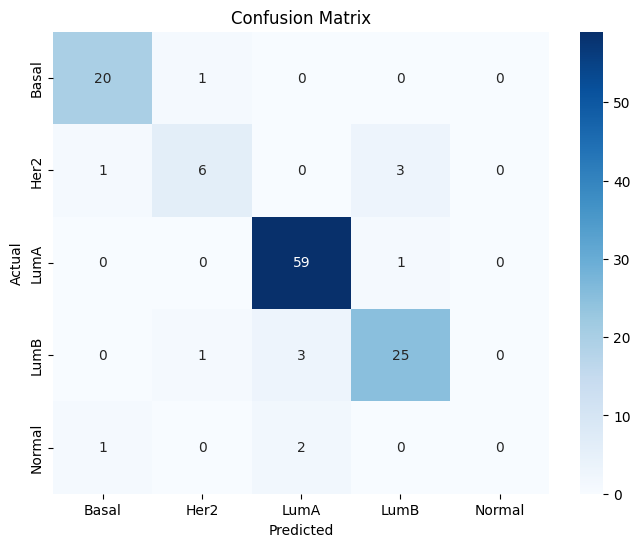

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Interpretation of Confusion Matrix

The confusion matrix shows how accurately the model predicts each breast cancer subtype.

Observations
LumA subtype is classified with highest accuracy because it has strong gene expression signatures.
Basal subtype also shows strong separation from other classes.
Some confusion occurs between:
LumA and LumB
Her2 and LumB

This happens because these subtypes share partially similar molecular patterns.

The diagonal values in the confusion matrix represent correct predictions, while off-diagonal values indicate misclassification.

Hypothesis-Driven Statistical Analysis

ANOVA Test for Gene Significance

Hypothesis testing is performed to identify genes significantly associated with PAM50 subtypes.

Null Hypothesis (H0)

Gene expression does not differ across breast cancer subtypes.

Alternative Hypothesis (H1)

Gene expression differs significantly across subtypes.

In [ ]:
from scipy.stats import f_oneway

significant_genes = []

for gene in selected_features:

    groups = []

    for subtype in y.unique():
        groups.append(
            df[df[target_col] == subtype][gene]
        )

    stat, p = f_oneway(*groups)

    if p < 0.05:
        significant_genes.append((gene, p))

significant_genes = sorted(
    significant_genes,
    key=lambda x: x[1]
)

print(significant_genes[:20])

[('FOXA1', np.float64(3.2105933283212113e-189)), ('ESR1', np.float64(5.264211008266475e-187)), ('MLPH', np.float64(7.981468451361129e-175)), ('AGR3', np.float64(2.0831201810779951e-159)), ('FOXC1', np.float64(7.092268855399499e-157)), ('TBC1D9', np.float64(8.162339669842424e-151)), ('GPR77', np.float64(3.1476515107136306e-142)), ('GATA3', np.float64(1.9406078166719206e-141)), ('CA12', np.float64(9.543934710044276e-141)), ('C6orf97', np.float64(2.0383368230830575e-140)), ('THSD4', np.float64(8.116370100222537e-135)), ('XBP1', np.float64(8.569452450966953e-135)), ('CT62', np.float64(1.025680592737115e-129)), ('ROPN1', np.float64(2.8205901422664085e-129)), ('PRR15', np.float64(3.086501788132336e-127)), ('DNALI1', np.float64(5.523354630440263e-127)), ('SPDEF', np.float64(1.0025351876440302e-126)), ('SLC44A4', np.float64(2.5796069803888402e-124)), ('LEMD1', np.float64(2.034794122183839e-122)), ('TFF3', np.float64(5.054057433543588e-122))]


Important Gene Extraction

In [ ]:
importance = best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Gene': selected_features,
    'Importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_df.head(20))

        Gene  Importance
17      MLPH    0.308334
65     GATA3    0.041157
86     CENPA    0.033593
57   MICALL1    0.031866
41      ESR1    0.031573
68     FOXA1    0.027343
30  PPP1R14C    0.021906
19     FOXC1    0.020947
77     SPDEF    0.018614
85     CENPN    0.017872
10    RABEP1    0.017563
25       MIA    0.015358
5       TTC8    0.013840
7    C4orf34    0.012846
73    KCNK15    0.010760
8      FSIP1    0.010209
6     TBC1D9    0.009749
2       ABAT    0.009174
45    GPR160    0.008489
89     GREB1    0.008092


**Visualization of Important Genes**

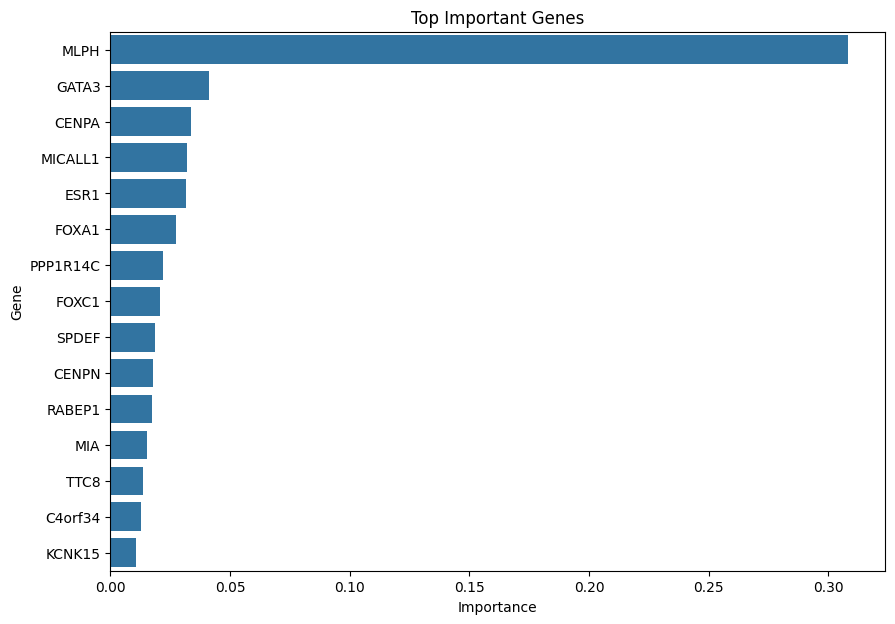

In [ ]:
top_genes = feature_importance_df.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    x='Importance',
    y='Gene',
    data=top_genes
)

plt.title("Top Important Genes")

plt.show()